## Initial testing
just getting some plots and basic analysis for the initial data we have

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [16]:
# def multi_lorentz(x, A, h1, g1, x0_1, h2, g2, x0_2, h3, g3, x0_3):
#     dip1 = h1 * (g1**2) / ((x - x0_1)**2 + g1**2)
#     dip2 = h2 * (g2**2) / ((x - x0_2)**2 + g2**2)
#     dip3 = h3 * (g3**2) / ((x - x0_3)**2 + g3**2)

#     return A - (dip1 + dip2 + dip3)

In [17]:
savename = "5s measurement Mar 4"
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 4 measurement/firstMeasurement-Mar04.csv')


# # Load the file, skipping the first two header rows
# df = pd.read_csv('./data/Mar 6 measurement/50sec_measurement.csv', skiprows=2, usecols=[0, 1, 2], names=['Sequence', 'CH1', 'CH2'])
# dfTimevals = pd.read_csv('./data/Mar 6 measurement/50sec_measurement.csv', skiprows=1, usecols=[3,4], names=['Start','Increment'])
#
# # Access the columns as arrays for your fitting function
# x = df['Sequence'].values
# y1 = df['CH1'].values
# y2 = df['CH2'].values
#
# timeStep = dfTimevals["Increment"].values[0]
#
# time = x * timeStep
# y2_norm = y2 - min(y2)
# y2_norm = y2_norm / max(y2_norm)

# filepath = './data/Mar 6 measurement/50sec_measurement.csv'
# df = pd.read_csv(filepath, skiprows=2, usecols=[0, 1, 2],
#                         names=['Sequence', 'CH1', 'CH2'])
# dfTimevals = pd.read_csv(filepath, skiprows=1, usecols=[3, 4],
#                          names=['Start', 'Increment'])
#
# # Access the columns as arrays for your fitting function
# x = df['Sequence'].values
# y1 = df['CH1'].values
# y2 = df['CH2'].values
#
# timeStep = dfTimevals["Increment"].values[0]
#
# time = x * timeStep
# y2_norm = y2 - min(y2)
# y2_norm = y2_norm / max(y2_norm)


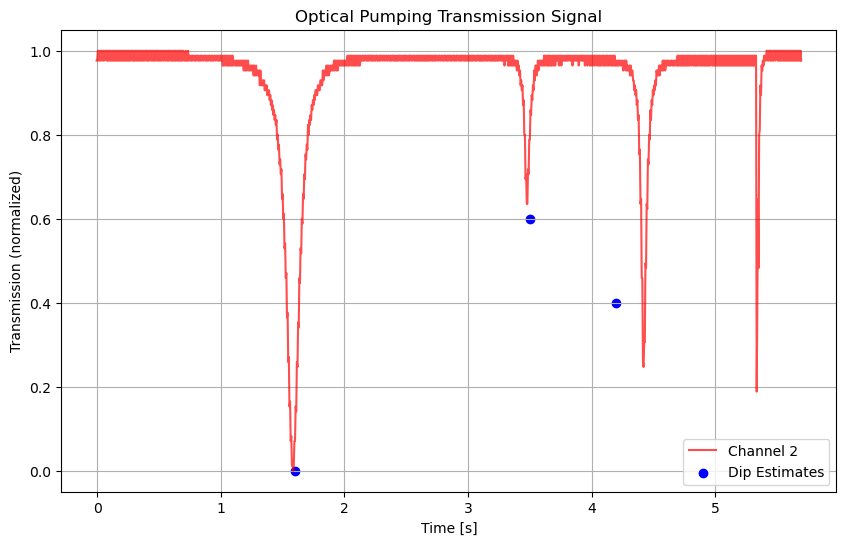

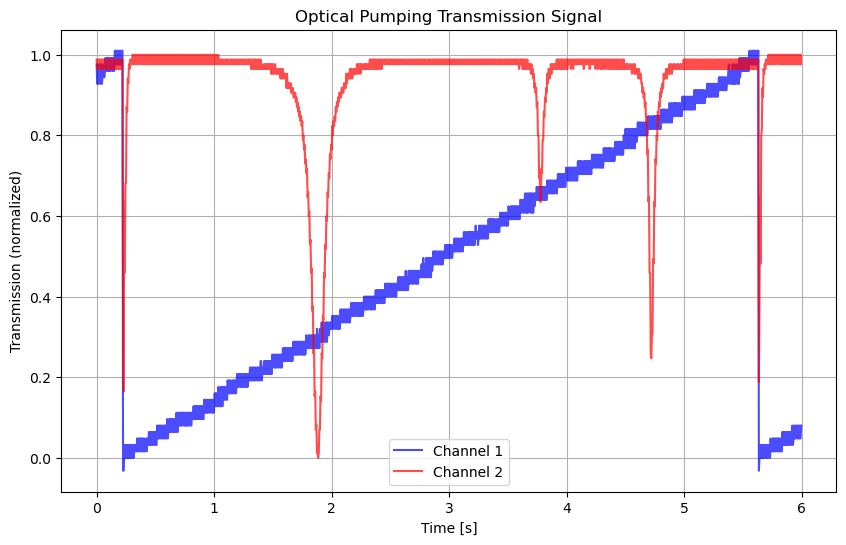

In [19]:
t0 = 0.3
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([1.9,3.8,4.5]) - t0
# x0_1 = 19
# x0_2 = 31.5
# x0_3 = 38

# print(nCut)


m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

plt.figure(figsize=(10, 6))
# Plot CH1 and CH2
plt.plot(time, y1, label='Channel 1', color='blue', alpha=0.7)
plt.plot(time, y2_norm, label='Channel 2', color='red', alpha=0.7)
# plt.scatter([x0_1,x0_2,x0_3], [0,0.6,0.4], label='Dip Estimates', color='blue')
# plt.plot(time,y2_norm, label='Channel 2 normalized', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Time [s]')
plt.ylabel('Transmission (normalized)')
plt.title('Optical Pumping Transmission Signal')
plt.legend()
plt.grid(True)
plt.savefig(savename, dpi=300)

plt.show()

In [11]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.multi_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0,bounds=bounds)
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9831912163183886
h1 0.9744795293412186
g1 0.05958246537619063
x0_1 1.5830270847112538
h2 0.33675300835728217
g2 0.022058811568267084
x0_2 3.4780593975987686
h3 0.7174932832793117
g3 0.024527445838022053
x0_3 4.42239473702954


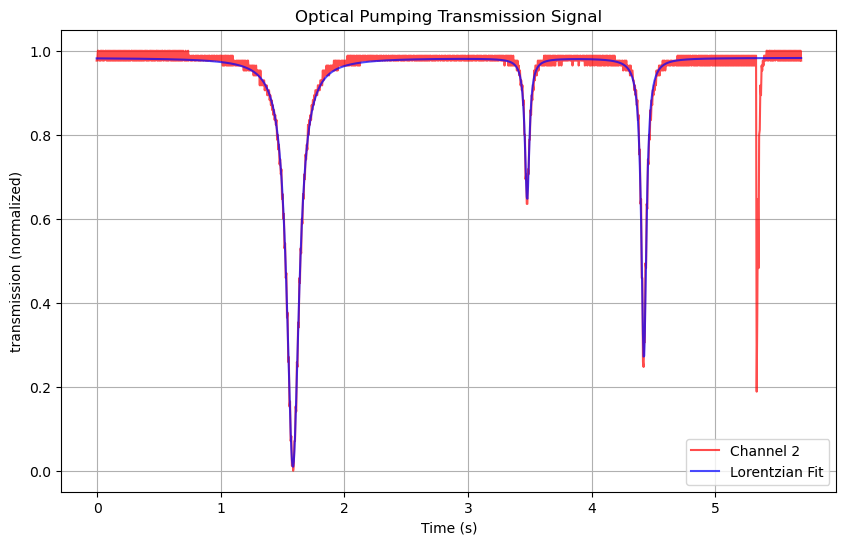

In [12]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, "fit to " + savename)
# plt.figure(figsize=(10, 6))
#
# # Plot CH1 and CH2
# # plt.plot(df['Sequence'], df['CH1'], label='Channel 1', color='blue', alpha=0.7)
# plt.plot(time_cutFirst, y2_norm_cutFirst, label='Channel 2', color='red', alpha=0.7)
# plt.plot(time, m.multi_lorentz(time,*popt), label='Lorentzian Fit', color='blue', alpha=0.7)
#
# # Labels and formatting
# plt.xlabel('Time (s)')
# plt.ylabel('transmission (normalized)')
# plt.title('Optical Pumping Transmission Signal')
# plt.legend()
# plt.grid(True)
#
# plt.show()

In [21]:
x0_1_fitted = popt[3] + t0
x0_2_fitted = popt[6] + t0
x0_3_fitted = popt[9] + t0

x0_1_index = (x0_1_fitted // (time[1] - time[0])).astype(int)
x0_2_index = (x0_2_fitted // (time[1] - time[0])).astype(int)
x0_3_index = (x0_3_fitted // (time[1] - time[0])).astype(int)

numAvg = 10


# print(x0_1_index, x0_2_index, x0_3_index)

v_1 = np.mean(y1[x0_1_index - numAvg: x0_1_index + numAvg])
v_2 = np.mean(y1[x0_2_index - numAvg: x0_2_index + numAvg])
v_3 = np.mean(y1[x0_3_index - numAvg: x0_3_index + numAvg])

# print(v_1, v_2, v_3)

# 0.6 * 10^-4 T/amp
# sense 1 Ohm, so 1V <-> 1A

VtoB = 0.6 * 10**(-4)

b_2 = (v_2 - v_1) * VtoB
b_3 = (v_3 - v_1) * VtoB


print(b_2, b_3)

376 755 944
0.2944000000000001 0.6544000000000001 0.8272000000000002
2.16e-05 3.1968e-05
